# 正规方程

In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# 1. [加载]加利福尼亚房价数据集
california = fetch_california_housing(data_home='./data')
# 转换为 DataFrame，方便查看
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

# # 显示前5行数据
# print(df.head())
# # 显示数据集的基本信息
# print(df.info())
# # 显示描述性统计信息
# print(df.describe())

# print("数据集的形状:", df.shape)


# 2. [分割]训练集和测试集，避免模型训练和评估出现数据泄漏
from sklearn.model_selection import train_test_split

# 选择特征变量X和目标变量y
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# 将数据分为训练集和测试集（例如80%训练，20%测试）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 3. [标准化]特征：让每个特征的均值为0，方差为1，有助于提高模型表现
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # 在训练集上拟合，并对训练集标准化
X_test_scaled = scaler.transform(X_test)        # 用相同的缩放参数对测试集标准化


# 4. 通过线性回归的“正规方程”解法直接[求解]最优参数
# 正规方程公式: θ = (X^T X)^(-1) X^T y
import numpy as np

# 增加截距项（偏置项），即在特征最前面加一列1
X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]  # 训练集特征加一列1
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]     # 测试集特征加一列1

# 计算正规方程，得到最优的θ参数
# np.dot 和 @ 在二维数组/矩阵的情景下是等价的，都代表矩阵乘法。这里可以用 @ 运算符替换 dot 方法：
theta_best = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train

# 用训练得到的参数进行预测
y_pred = X_test_b.dot(theta_best)

# 5. 简单评[估模]型的表现（均方误差）
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
# 计算训练集上的预测结果和均方误差
y_train_pred = X_train_b.dot(theta_best)
mse_train = mean_squared_error(y_train, y_train_pred)
print("正规方程：训练集均方误差(MSE)：", mse_train)
print("正规方程：测试集均方误差(MSE)：", mse)

# 正规方程说明：
# 正规方程是一种不需要迭代、可以直接求解线性回归模型最优参数的解析方法。
# 它利用如下公式直接计算参数θ，使损失函数最小：
#      θ = (X^T X)^(-1) X^T y
# 其中，X是样本特征矩阵，y是真实标签向量。
# 该方法仅适用于特征数量不是特别巨大的情况，因计算逆矩阵很耗时。

正规方程：训练集均方误差(MSE)： 0.5179331255246699
正规方程：测试集均方误差(MSE)： 0.5558915986952441


# 梯度下降

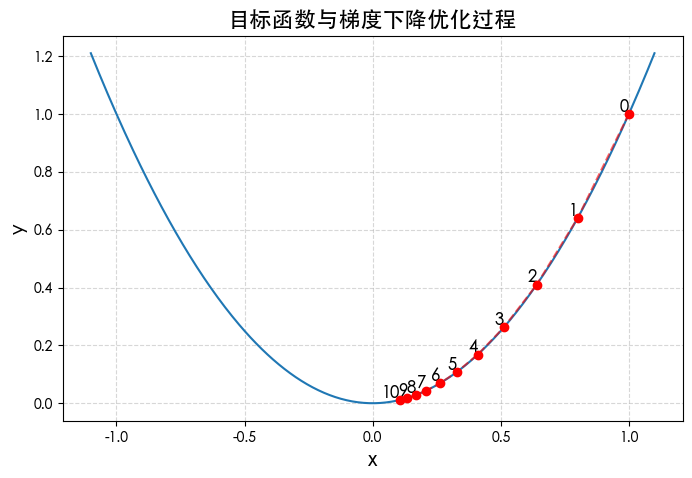

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 目标函数和梯度
def f(x):
    return x**2

def grad_f(x):
    return 2 * x

# 初始化参数
x = 1
learning_rate = 0.1
steps = 10

x_history = [x]
y_history = [f(x)]

# 梯度下降
for i in range(steps):
    x = x - learning_rate * grad_f(x)
    x_history.append(x)
    y_history.append(f(x))

# 画出目标函数曲线
from matplotlib import rcParams

# 设置 MacOS 可用中文字体
rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang SC', 'STHeiti', 'Arial Unicode MS', 'sans-serif']
rcParams['axes.unicode_minus'] = False  # 正确显示负号

x_plot = np.linspace(-1.1, 1.1, 400)
y_plot = f(x_plot)

plt.figure(figsize=(8, 5))
plt.plot(x_plot, y_plot, label='目标函数 $y = x^2$')
plt.scatter(x_history, y_history, color='red', zorder=5, label='梯度下降步')
plt.plot(x_history, y_history, color='red', linestyle='--', alpha=0.6)

# 标注每个步骤
for i, (xi, yi) in enumerate(zip(x_history, y_history)):
    plt.text(xi, yi, f'{i}', fontsize=12, va='bottom', ha='right')

plt.title('目标函数与梯度下降优化过程', fontsize=16)
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# L1 正则化 - Lasso

(100, 1)
(100, 10)
lasso回归MSE: 1.4716583289021283
lasso回归权重w: [ 0.00000000e+00  0.00000000e+00  4.63689470e-02  0.00000000e+00
  5.45675192e-02  2.51142736e-02 -7.87474155e-03 -1.58092058e-03
  2.71680347e-04 -8.81153578e-05]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.213010e+01, tolerance: 4.835e-02
  model = cd_fast.enet_coordinate_descent(


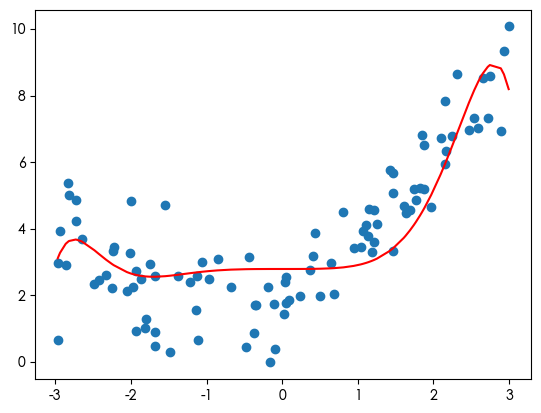

array([ 0.00000000e+00,  0.00000000e+00,  4.63689470e-02,  0.00000000e+00,
        5.45675192e-02,  2.51142736e-02, -7.87474155e-03, -1.58092058e-03,
        2.71680347e-04, -8.81153578e-05])

In [ ]:
from sklearn.linear_model import Lasso

# 随机种子
np.random.seed(22)

# 1.准备数据X,y增加噪声
# 创建100个数据,在[-3,3]中取值,值是均匀分布的
x=np.random.uniform(-3,3,size=100)

# y=0.5x^2+x+2
# np.random.normal(0,1,size=100):增加噪声,噪声值为均值为0,方差为1的正态分布数据
y=0.5*x**2+x+2+np.random.normal(0,1,size=100)

# 2.创建模型*
# alpha:正则化参数
model=Lasso(alpha=1.0)

# 3.模型训练
# 训练数据是二维的,所以X需要reshape成二维的
# -1的作用是告诉numpy,根据y的维度自动确定X的维度
# 1是列数
X=x.reshape(-1,1)
print(X.shape)

# 堆叠，增加多次项
X2=np.hstack([X,X**2,X**3,X**4,X**5,X**6,X**7,X**8,X**9,X**10])
print(X2.shape)
model.fit(X2,y)

# 4.模型预测
y_predict=model.predict(X2)

# 5.模型评估
mse=mean_squared_error(y,y_predict)
print("lasso回归MSE:",mse)
print("lasso回归权重w:",model.coef_)

# 6.绘制图像
plt.scatter(x,y)

# 画图plot折线图时需要对x进行排序,取x排序后对应的y值
plt.plot(np.sort(x),y_predict[np.argsort(x)],color='r')
plt.show()

model.coef_

# L2 正则化 - 岭回归

(100, 1)
(100, 10)
Ridge回归MSE: 0.8695190530707885
Ridge回归权重w: [ 0.53866413  0.51997384  0.02327666  0.12644528  0.12024745 -0.06716686
 -0.03377833  0.01191641  0.00235101 -0.00068853]


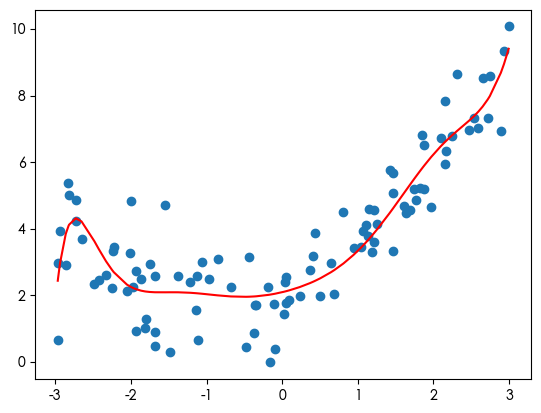

array([ 0.53866413,  0.51997384,  0.02327666,  0.12644528,  0.12024745,
       -0.06716686, -0.03377833,  0.01191641,  0.00235101, -0.00068853])

In [ ]:
#岭回归
from sklearn.linear_model import Ridge

# 随机种子
np.random.seed(22)

# 1.准备数据X,y增加噪声
# 创建100个数据,在[-3,3]中取值,值是均匀分布的
x=np.random.uniform(-3,3,size=100)

# y=0.5x^2+x+2
# np.random.normal(0,1,size=100):增加噪声,噪声值为均值为0,方差为1的正态分布数据
y=0.5*x**2+x+2+np.random.normal(0,1,size=100)

# 2.创建模型*
# alpha:正则化参数
model=Ridge(alpha=5.0)

# 3.模型训练
# 训练数据是二维的,所以X需要reshape成二维的
# -1的作用是告诉numpy,根据y的维度自动确定X的维度
# 1是列数
X=x.reshape(-1,1)
print(X.shape)

# 堆叠，增加多次项
X2=np.hstack([X,X**2,X**3,X**4,X**5,X**6,X**7,X**8,X**9,X**10])
print(X2.shape)
model.fit(X2,y)

# 4.模型预测
y_predict=model.predict(X2)

# 5.模型评估
mse=mean_squared_error(y,y_predict)
print("Ridge回归MSE:",mse)
print("Ridge回归权重w:",model.coef_)

# 6.绘制图像
plt.scatter(x,y)
# 画图plot折线图时需要对x进行排序,取x排序后对应的y值
plt.plot(np.sort(x),y_predict[np.argsort(x)],color='r')
plt.show()

model.coef_

# 逻辑回归

In [ ]:
# 癌症预测分类代码实现
# 1.导包
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.preprocessing import StandardScaler

# 2.读取数据
data=pd.read_csv('data/breast-cancer-wisconsin.csv')

# 3.数据预处理(缺失值处理)
data=data.replace('?',np.nan)
data=data.dropna()

# 4.确定特征值，目标值
X=data.iloc[:,1:10]#去掉第一列和最后一列
y=data.iloc[:,10]#获取最后一列

# 5.划分数据集
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=22)

# 6.特征工程(标准化)
std=StandardScaler()
X_train=std.fit_transform(X_train)
X_test=std.transform(X_test)

# 7.创建逻辑回归模型
model=LogisticRegression()

# 8.训练模型
model.fit(X_train,y_train)

# 9.模型预测
y_predict=model.predict(X_test)
print("预测结果:\n",y_predict)
print("真实结果:\n",y_test)

# 10.模型评估
print("准确率:\n",model.score(X_test,y_test))

预测结果:
 [2 2 2 2 4 2 2 2 2 2 2 2 2 2 2 4 4 2 2 2 2 2 4 4 4 4 2 4 2 2 2 2 4 2 2 2 2
 2 2 4 2 4 4 2 4 4 2 2 4 4 2 2 4 4 2 4 2 2 2 2 4 2 4 4 2 4 4 2 4 2 2 2 2 2
 2 4 2 4 2 2 2 4 2 2 2 4 2 4 2 2 2 2 2 4 4 2 2 2 4 4 4 2 4 4 2 2 4 4 4 2 2
 2 2 4 4 2 4 2 2 2 4 2 2 2 4 4 2 4 2 4 4 2 4 2 2 2 2 2 4 2 2 2 4 2 2 4 4 4
 2 4 4 4 2 2 4 4 4 4 2 2 2 2 2 2 2 2 2 2 2 4 2]
真实结果:
 388    2
32     2
272    4
476    2
271    4
      ..
297    2
584    2
256    2
43     4
498    2
Name: 2.1, Length: 171, dtype: int64
准确率:
 0.9532163742690059
